In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── CONFIG ────────────────────────────────────────────────────────────────────
DAT_PATH   = "data/processed_wac_100m_new/sigma/100/craters_aug.dat"   # ← change to your .dat file
CHANNELS   = 1
OUTPUT_SIZE = 128
# Shape is inferred automatically; or set explicitly:
# SHAPE = (50000, 1, 128, 128)
SHAPE = None   # None = auto-infer from file size
SAMPLE_N   = 5_000   # samples used for statistics (avoid loading everything)
N_EXAMPLES = 10      # example crops to plot


In [2]:
import os

def infer_shape(path, channels, size):
    n_bytes  = os.path.getsize(path)
    n_pixels = channels * size * size
    N        = n_bytes // (4 * n_pixels)   # float32 = 4 bytes
    assert n_bytes == N * 4 * n_pixels, (
        f"File size {n_bytes} not divisible by {4*n_pixels}. "
        "Set SHAPE manually."
    )
    return (N, channels, size, size)

shape = SHAPE or infer_shape(DAT_PATH, CHANNELS, OUTPUT_SIZE)
mm = np.memmap(DAT_PATH, dtype=np.float32, mode="r", shape=shape)

print(f"shape : {mm.shape}")
print(f"dtype : {mm.dtype}")
print(f"size  : {mm.nbytes / 1e9:.3f} GB")


shape : (152103, 1, 128, 128)
dtype : float32
size  : 9.968 GB


In [5]:
sample = mm[:min(SAMPLE_N, len(mm))]
safe   = np.nan_to_num(sample, nan=0.0, posinf=1.0, neginf=0.0)
flat   = safe.reshape(len(safe), -1)

per_mean = flat.mean(axis=1)
per_std  = flat.std(axis=1)

stats = {
    "N"        : len(mm),
    "min"      : float(safe.min()),
    "max"      : float(safe.max()),
    "mean"     : float(safe.mean()),
    "std"      : float(safe.std()),
    "p1"       : float(np.percentile(safe,  1)),
    "p99"      : float(np.percentile(safe, 99)),
    "nan_%"    : 100 * np.isnan(sample).mean(),
    "inf_%"    : 100 * np.isinf(sample).mean(),
    "zero_%"   : 100 * (safe == 0).mean(),
    "below0_%" : 100 * (sample < 0).mean(),
    "above1_%" : 100 * (sample > 1).mean(),
    "flat_%"   : 100 * (per_std < 1e-6).mean(),
}

flag = lambda v: "⚠️" if v > 0 else "✅"

print(f"{'='*52}")
print(f"  Samples  : {min(SAMPLE_N, len(mm)):,} / {len(mm):,}")
print(f"  Range    : [{stats['min']:.4f}, {stats['max']:.4f}]")
print(f"  Mean/Std : {stats['mean']:.4f} / {stats['std']:.4f}")
print(f"  p1 / p99 : {stats['p1']:.4f} / {stats['p99']:.4f}")
print(f"{'─'*52}")
print(f"  NaN      : {stats['nan_%']:.4f}%  {flag(stats['nan_%'])}")
print(f"  Inf      : {stats['inf_%']:.4f}%  {flag(stats['inf_%'])}")
print(f"  Zeros    : {stats['zero_%']:.2f}%")
print(f"  < 0      : {stats['below0_%']:.4f}%  {flag(stats['below0_%'])}")
print(f"  > 1      : {stats['above1_%']:.4f}%  {flag(stats['above1_%'])}")
print(f"  Flat     : {stats['flat_%']:.2f}%  {flag(stats['flat_%'])}")
print(f"{'─'*52}")
print(f"  Per-sample mean → μ={per_mean.mean():.4f}  σ={per_mean.std():.4f}")
print(f"  Per-sample std  → μ={per_std.mean():.4f}  σ={per_std.std():.4f}")
print(f"{'='*52}")


  Samples  : 5,000 / 152,103
  Range    : [0.0000, 1.0000]
  Mean/Std : 0.4438 / 0.1846
  p1 / p99 : 0.0419 / 0.8784
────────────────────────────────────────────────────
  NaN      : 0.0000%  ✅
  Inf      : 0.0000%  ✅
  Zeros    : 0.01%
  < 0      : 0.0000%  ✅
  > 1      : 0.0000%  ✅
  Flat     : 0.00%  ✅
────────────────────────────────────────────────────
  Per-sample mean → μ=0.4438  σ=0.0693
  Per-sample std  → μ=0.1668  σ=0.0381


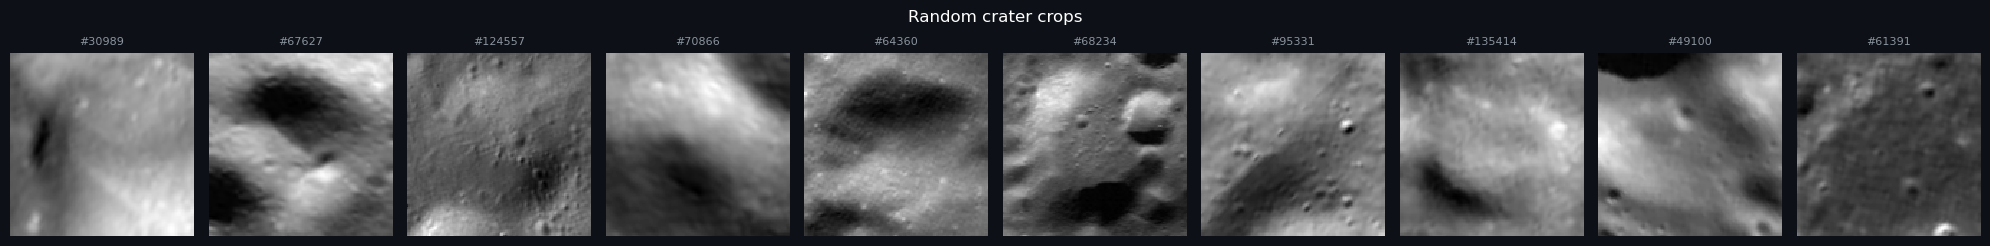

In [6]:
idx  = np.random.choice(len(mm), N_EXAMPLES, replace=False)
imgs = np.nan_to_num(mm[idx], nan=0, posinf=1, neginf=0)

fig, axes = plt.subplots(1, N_EXAMPLES, figsize=(2 * N_EXAMPLES, 2.5),
                         facecolor="#0d1117")
for j, ax in enumerate(axes):
    img = imgs[j, 0] if imgs.shape[1] == 1 else imgs[j].transpose(1, 2, 0)
    ax.imshow(img, cmap="gray", vmin=0, vmax=1, interpolation="nearest")
    ax.set_title(f"#{idx[j]}", color="#8b949e", fontsize=8)
    ax.axis("off")

fig.suptitle("Random crater crops", color="white", fontsize=12)
plt.tight_layout()
plt.show()


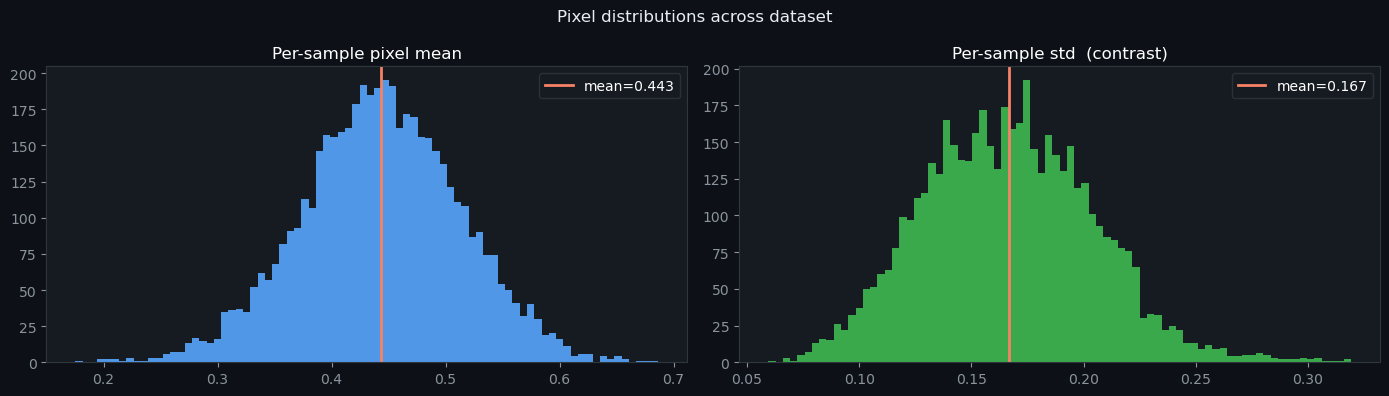

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4), facecolor="#0d1117")

for ax in (ax1, ax2):
    ax.set_facecolor("#161b22")
    for s in ax.spines.values(): s.set_edgecolor("#30363d")
    ax.tick_params(colors="#8b949e")

ax1.hist(per_mean, bins=80, color="#58a6ff", edgecolor="none", alpha=0.9)
ax1.axvline(per_mean.mean(), color="#f78166", lw=2,
            label=f"mean={per_mean.mean():.3f}")
ax1.set_title("Per-sample pixel mean", color="white")
ax1.legend(labelcolor="white", facecolor="#161b22", edgecolor="#30363d")

ax2.hist(per_std, bins=80, color="#3fb950", edgecolor="none", alpha=0.9)
ax2.axvline(per_std.mean(), color="#f78166", lw=2,
            label=f"mean={per_std.mean():.3f}")
ax2.set_title("Per-sample std  (contrast)", color="white")
ax2.legend(labelcolor="white", facecolor="#161b22", edgecolor="#30363d")

fig.suptitle("Pixel distributions across dataset", color="#e6edf3", fontsize=12)
fig.patch.set_facecolor("#0d1117")
plt.tight_layout()
plt.show()


Latents shape: (152103, 64)
Fitting KMeans k=4...
Inertia: 30756.39

Cluster sizes — min:19261  max:47147  mean:38026  std:11287
Empty clusters: 0
Tiny (<10):     0

Computing clustering statistics (subsampled 10k)...
  Silhouette score     : 0.1335  (higher better, range -1 to 1)
  Davies-Bouldin score : 1.9109   (lower better)
  Calinski-Harabasz    : 2328.0  (higher better)
  Inertia (WCSS)       : 30756.39

Computing PCA...
PCA variance explained: 53.6%  (PC1=39.3%  PC2=14.3%)
Saved → kmeans4_pca.png

Computing UMAP (this takes a few minutes)...
UMAP(n_jobs=1, n_neighbors=30, random_state=42, verbose=True)
Tue Apr 28 11:53:17 2026 Construct fuzzy simplicial set
Tue Apr 28 11:53:17 2026 Finding Nearest Neighbors
Tue Apr 28 11:53:17 2026 Building RP forest with 25 trees


/home/kinreich/autoencoder_project/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Tue Apr 28 11:53:18 2026 NN descent for 17 iterations
	 1  /  17
	 2  /  17
	 3  /  17
	Stopping threshold met -- exiting after 3 iterations
Tue Apr 28 11:53:30 2026 Finished Nearest Neighbor Search
Tue Apr 28 11:53:31 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Tue Apr 28 11:54:51 2026 Finished embedding
Saved → kmeans4_umap.png
Saved → kmeans4_sizes.png


ValueError: Cannot take a larger sample than population when replace is False

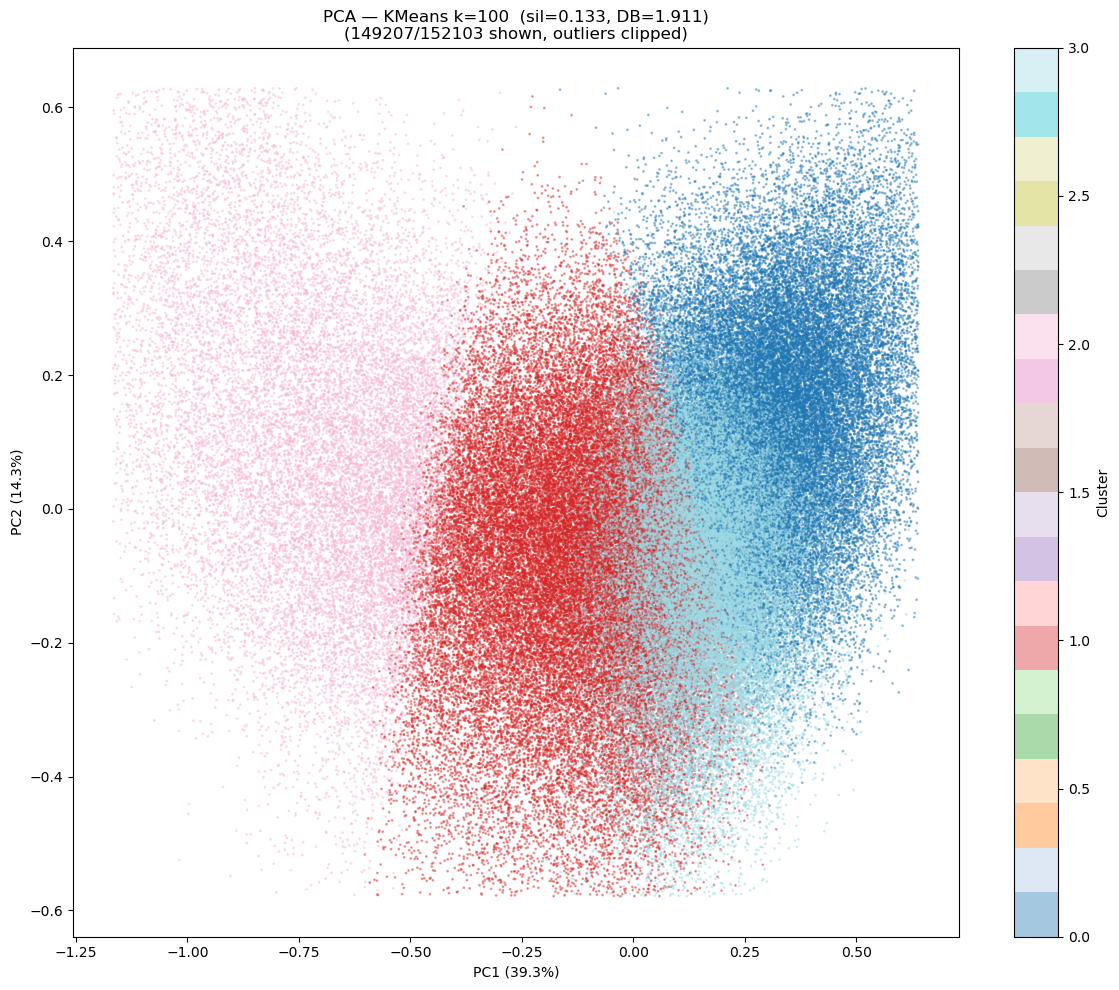

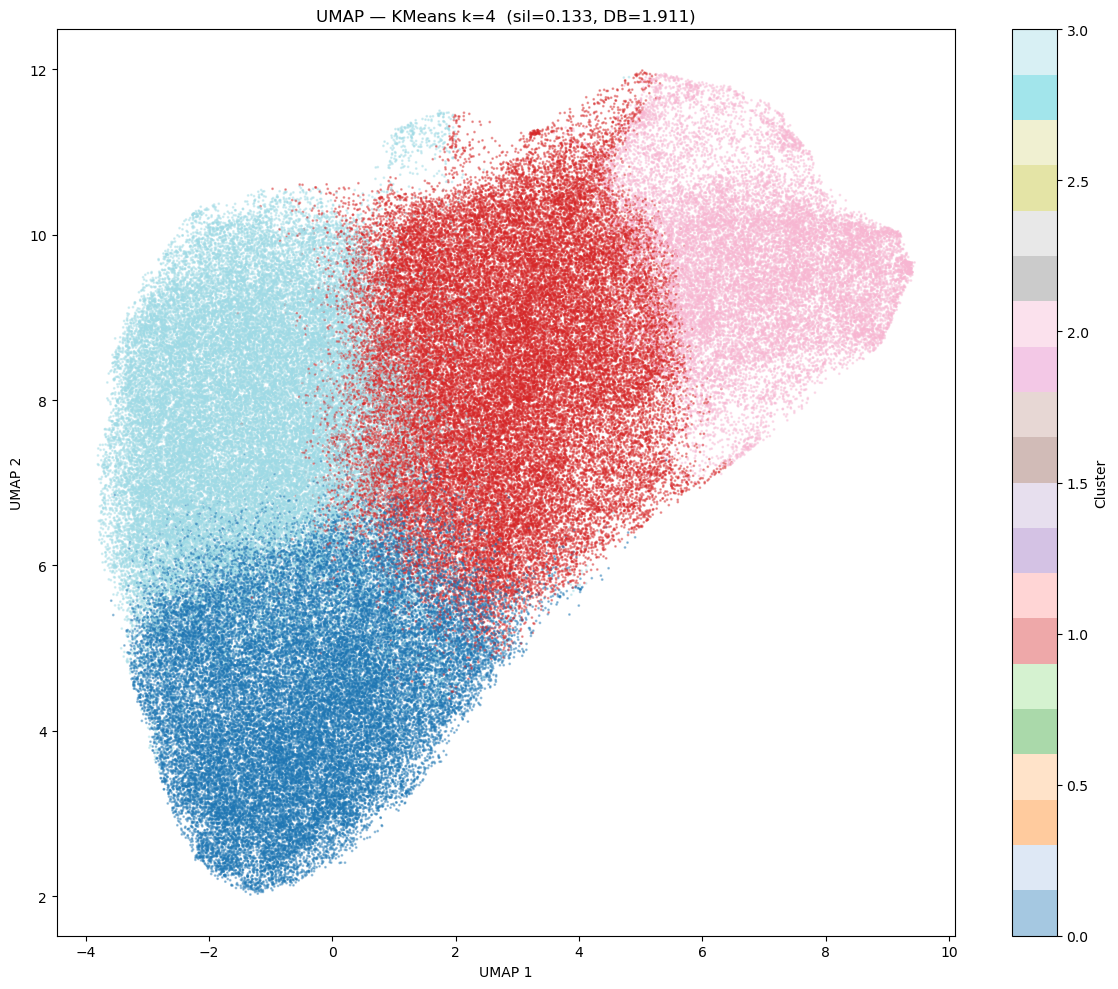

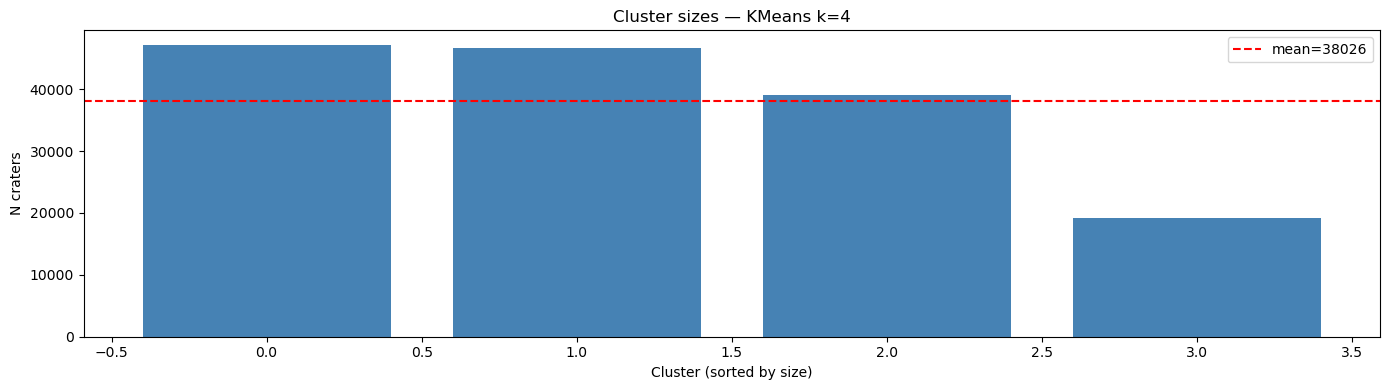

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import torchvision.transforms.functional as TF
import torch
import os
import umap

EXTRACT_SIZE = 320
INPUT_SIZE   = 224

# ── load ──────────────────────────────────────────────────────────────────
latents = np.load('logs/mae/processed_wac_100m_new/100/3.0_10.0_300_mask0.75/models/latent_vectors.npy')
path    = 'data/processed_wac_100m_new/sigma/100/craters.dat'
N       = os.path.getsize(path) // (EXTRACT_SIZE * EXTRACT_SIZE * 1 * 4)
craters = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, EXTRACT_SIZE, EXTRACT_SIZE))
print(f"Latents shape: {latents.shape}")

# ── kmeans 100 ────────────────────────────────────────────────────────────
print("Fitting KMeans k=4...")
km     = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=4096, n_init=5)
labels = km.fit_predict(latents)
print(f"Inertia: {km.inertia_:.2f}")

sizes = np.bincount(labels)
print(f"\nCluster sizes — min:{sizes.min()}  max:{sizes.max()}  mean:{sizes.mean():.0f}  std:{sizes.std():.0f}")
print(f"Empty clusters: {(sizes == 0).sum()}")
print(f"Tiny (<10):     {(sizes < 10).sum()}")

# ── statistics ────────────────────────────────────────────────────────────
# subsample for metrics — full dataset is slow for silhouette
print("\nComputing clustering statistics (subsampled 10k)...")
sub_idx = np.random.default_rng(42).choice(len(latents), size=min(10000, len(latents)), replace=False)
sil  = silhouette_score(latents[sub_idx], labels[sub_idx])
db   = davies_bouldin_score(latents[sub_idx], labels[sub_idx])
ch   = calinski_harabasz_score(latents[sub_idx], labels[sub_idx])
print(f"  Silhouette score     : {sil:.4f}  (higher better, range -1 to 1)")
print(f"  Davies-Bouldin score : {db:.4f}   (lower better)")
print(f"  Calinski-Harabasz    : {ch:.1f}  (higher better)")
print(f"  Inertia (WCSS)       : {km.inertia_:.2f}")

# ── PCA ───────────────────────────────────────────────────────────────────
print("\nComputing PCA...")
pca    = PCA(n_components=2)
coords_pca = pca.fit_transform(latents)
ev     = pca.explained_variance_ratio_
print(f"PCA variance explained: {ev.sum()*100:.1f}%  (PC1={ev[0]*100:.1f}%  PC2={ev[1]*100:.1f}%)")

p = np.percentile(coords_pca, [0.5, 99.5], axis=0)
mask_plot = (
    (coords_pca[:, 0] > p[0,0]) & (coords_pca[:, 0] < p[1,0]) &
    (coords_pca[:, 1] > p[0,1]) & (coords_pca[:, 1] < p[1,1])
)

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(coords_pca[mask_plot, 0], coords_pca[mask_plot, 1],
                c=labels[mask_plot], cmap='tab20', s=1, alpha=0.4)
ax.set_title(f"PCA — KMeans k=100  (sil={sil:.3f}, DB={db:.3f})\n"
             f"({mask_plot.sum()}/{N} shown, outliers clipped)")
ax.set_xlabel(f"PC1 ({ev[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({ev[1]*100:.1f}%)")
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('kmeans4_pca.png', dpi=200)
print("Saved → kmeans4_pca.png")

# ── UMAP ──────────────────────────────────────────────────────────────────
print("\nComputing UMAP (this takes a few minutes)...")
reducer    = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1,
                       random_state=42, verbose=True)
coords_umap = reducer.fit_transform(latents)

fig, ax = plt.subplots(figsize=(12, 10))
sc = ax.scatter(coords_umap[:, 0], coords_umap[:, 1],
                c=labels, cmap='tab20', s=1, alpha=0.4)
ax.set_title(f"UMAP — KMeans k=4  (sil={sil:.3f}, DB={db:.3f})")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.colorbar(sc, ax=ax, label='Cluster')
plt.tight_layout()
plt.savefig('kmeans4_umap.png', dpi=200)
print("Saved → kmeans4_umap.png")

# ── cluster size histogram ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(range(4), sorted(sizes, reverse=True), color='steelblue')
ax.set_xlabel('Cluster (sorted by size)')
ax.set_ylabel('N craters')
ax.set_title('Cluster sizes — KMeans k=4')
ax.axhline(sizes.mean(), color='red', linestyle='--', label=f'mean={sizes.mean():.0f}')
ax.legend()
plt.tight_layout()
plt.savefig('kmeans4_sizes.png', dpi=150)
print("Saved → kmeans4_sizes.png")

# ── 5 random examples per cluster ─────────────────────────────────────────
rng           = np.random.default_rng(42)
show_clusters = rng.choice(4, size=12, replace=False)
n_cols        = 4

fig, axes = plt.subplots(12, n_cols, figsize=(n_cols*2, 12*2))
for row, k in enumerate(show_clusters):
    idx_k   = np.where(labels == k)[0]
    samples = rng.choice(idx_k, size=min(n_cols, len(idx_k)), replace=False)
    for col in range(n_cols):
        ax = axes[row, col]
        if col < len(samples):
            img = TF.center_crop(
                torch.from_numpy(np.array(craters[samples[col], 0])).unsqueeze(0),
                INPUT_SIZE
            ).squeeze().numpy()
            ax.imshow(img, cmap='gray', vmin=0, vmax=1)
            if col == 0:
                ax.set_ylabel(f"k={k}\nn={len(idx_k)}", fontsize=8)
        ax.axis('off')

plt.suptitle("5 random craters from 12 random clusters (KMeans k=4)", fontsize=12)
plt.tight_layout()
plt.savefig('kmeans4_examples.png', dpi=150)
print("Saved → kmeans4_examples.png")

# ── average crater per cluster ────────────────────────────────────────────
# layout: 10 rows × 10 cols = all 100 clusters, sorted by size descending
print("\nComputing average crater per cluster...")
cluster_order = np.argsort(sizes)[::-1]   # largest first

n_rows, n_cols = 2, 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*2, n_rows*2))

for pos, k in enumerate(cluster_order):
    ax      = axes[pos // n_cols, pos % n_cols]
    idx_k   = np.where(labels == k)[0]

    # average over up to 200 random samples per cluster (memory efficient)
    sample  = rng.choice(idx_k, size=min(200, len(idx_k)), replace=False)
    avg_img = np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=np.float32)
    for i in sample:
        img = TF.center_crop(
            torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0),
            INPUT_SIZE
        ).squeeze().numpy()
        avg_img += img
    avg_img /= len(sample)

    ax.imshow(avg_img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f"k={k}\nn={sizes[k]}", fontsize=6)
    ax.axis('off')

plt.suptitle("Average crater per cluster (sorted by size, largest first)", fontsize=12)
plt.tight_layout()
plt.savefig('kmeans4_averages.png', dpi=200)
print("Saved → kmeans4_averages.png")

print("\n=== Summary ===")
print(f"  Silhouette     : {sil:.4f}")
print(f"  Davies-Bouldin : {db:.4f}")
print(f"  Calinski-Harabasz: {ch:.1f}")
print(f"  Cluster sizes  : min={sizes.min()}  max={sizes.max()}  mean={sizes.mean():.0f}")

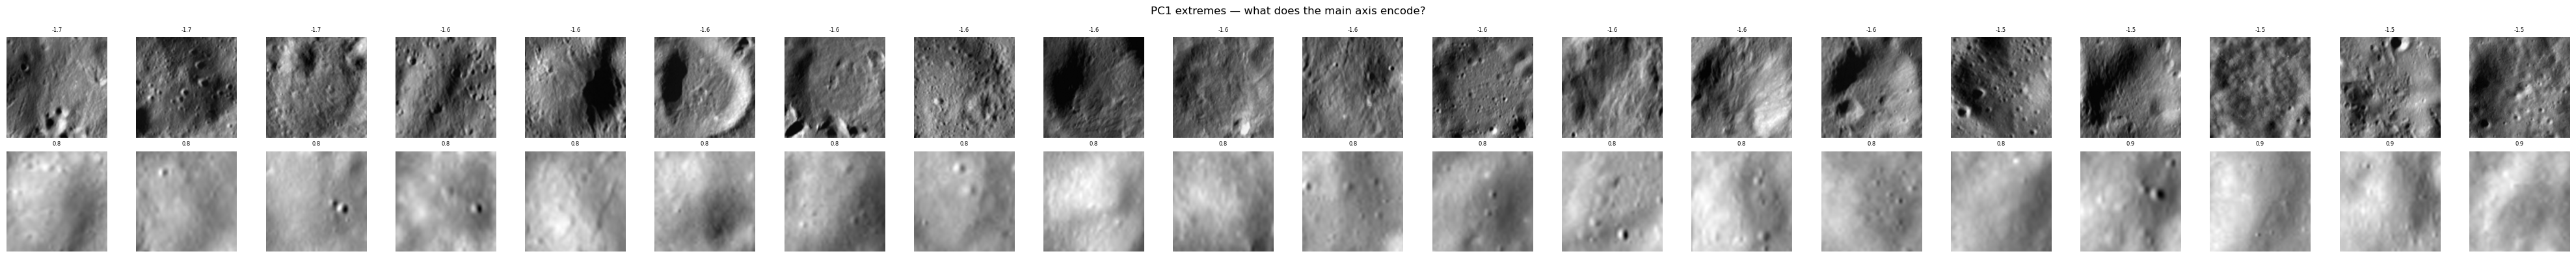

In [10]:
# sort all craters by PC1 value and look at the extremes
pc1_vals = coords_pca[:, 0]
low_idx  = np.argsort(pc1_vals)[:20]   # most negative PC1
high_idx = np.argsort(pc1_vals)[-20:]  # most positive PC1

fig, axes = plt.subplots(2, 20, figsize=(40, 4))
fig.suptitle("PC1 extremes — what does the main axis encode?")
for j, i in enumerate(low_idx):
    img = TF.center_crop(
        torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), 224
    ).squeeze().numpy()
    axes[0, j].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f"{pc1_vals[i]:.1f}", fontsize=6)
    axes[0, j].axis('off')

for j, i in enumerate(high_idx):
    img = TF.center_crop(
        torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), 224
    ).squeeze().numpy()
    axes[1, j].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title(f"{pc1_vals[i]:.1f}", fontsize=6)
    axes[1, j].axis('off')

axes[0, 0].set_ylabel("Low PC1", fontsize=10)
axes[1, 0].set_ylabel("High PC1", fontsize=10)
plt.tight_layout()
plt.savefig('pc1_extremes.png', dpi=200)

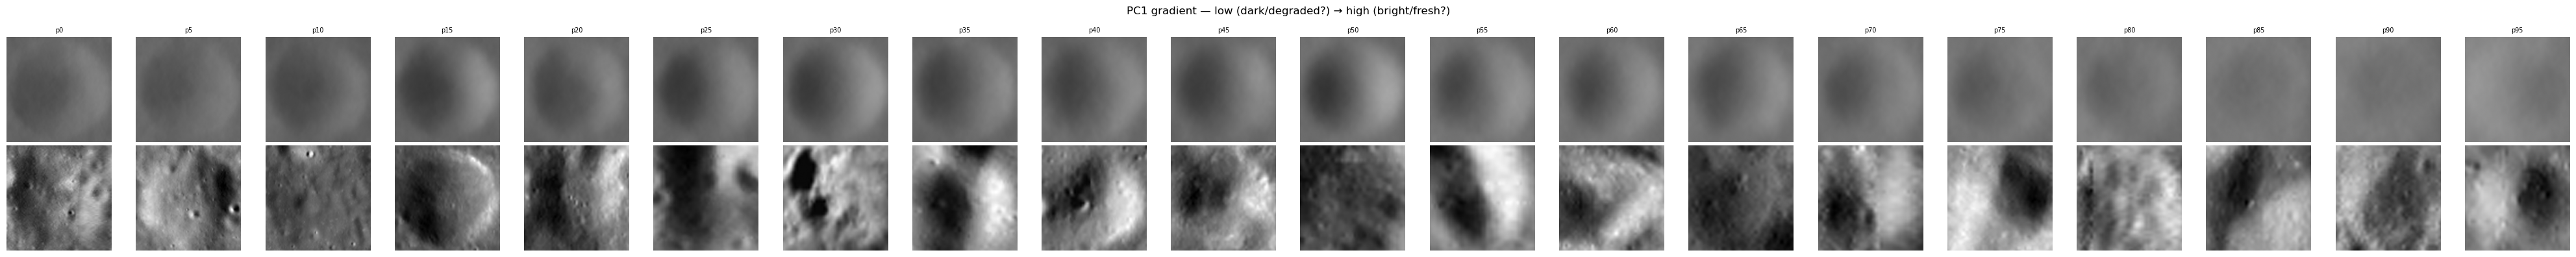

In [13]:
# instead of discrete clusters, treat PC1 as a continuous spectrum
# bin into 20 percentile slices and show average crater per bin
n_bins   = 20
pc1_vals = coords_pca[:, 0]
bins     = np.percentile(pc1_vals, np.linspace(0, 100, n_bins+1))

fig, axes = plt.subplots(2, n_bins, figsize=(n_bins*2, 4))
rng = np.random.default_rng(42)

for b in range(n_bins):
    mask   = (pc1_vals >= bins[b]) & (pc1_vals < bins[b+1])
    idx_b  = np.where(mask)[0]
    sample = rng.choice(idx_b, size=min(100, len(idx_b)), replace=False)

    # average image for this bin
    avg = np.zeros((INPUT_SIZE, INPUT_SIZE), dtype=np.float32)
    for i in sample:
        avg += TF.center_crop(
            torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), INPUT_SIZE
        ).squeeze().numpy()
    avg /= len(sample)

    axes[0, b].imshow(avg, cmap='gray', vmin=0, vmax=1)
    axes[0, b].set_title(f"p{b*5}", fontsize=7)
    axes[0, b].axis('off')

    # random example from this bin
    ex = rng.choice(idx_b)
    img = TF.center_crop(
        torch.from_numpy(np.array(craters[ex, 0])).unsqueeze(0), INPUT_SIZE
    ).squeeze().numpy()
    axes[1, b].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[1, b].axis('off')

axes[0, 0].set_ylabel("Average", fontsize=9)
axes[1, 0].set_ylabel("Example", fontsize=9)
plt.suptitle("PC1 gradient — low (dark/degraded?) → high (bright/fresh?)")
plt.tight_layout()
plt.savefig('pc1_gradient.png', dpi=200)

  0/152103
  20000/152103
  40000/152103
  60000/152103
  80000/152103
  100000/152103
  120000/152103
  140000/152103


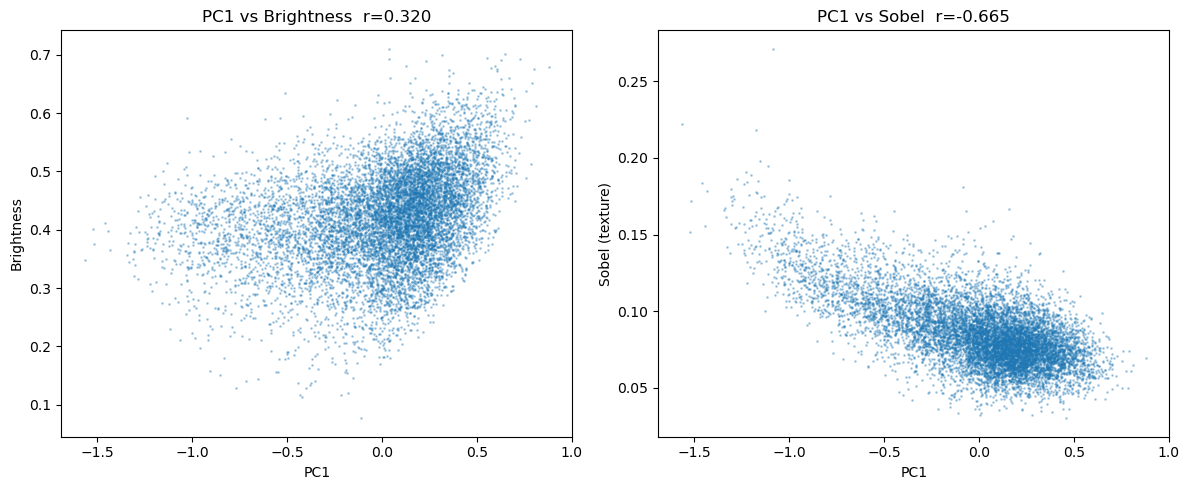

In [15]:
from scipy import ndimage

batch_size = 2000
brightness = np.zeros(N)
sobel_vals = np.zeros(N)

for i in range(0, N, batch_size):
    if i % 20000 == 0: print(f"  {i}/{N}")
    batch = np.array(craters[i:i+batch_size, 0])
    # center crop
    batch_t = TF.center_crop(torch.from_numpy(batch).unsqueeze(1), INPUT_SIZE).squeeze(1).numpy()
    brightness[i:i+batch_size] = batch_t.mean(axis=(1,2))
    for j, img in enumerate(batch_t):
        sx = ndimage.sobel(img, axis=0)
        sy = ndimage.sobel(img, axis=1)
        sobel_vals[i+j] = np.sqrt(sx**2 + sy**2).mean()

# scatter PC1 vs brightness and sobel
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub = np.random.default_rng(42).choice(N, size=10000, replace=False)

axes[0].scatter(coords_pca[sub, 0], brightness[sub], s=1, alpha=0.3)
axes[0].set_xlabel("PC1"); axes[0].set_ylabel("Brightness")
axes[0].set_title(f"PC1 vs Brightness  r={np.corrcoef(coords_pca[:,0], brightness)[0,1]:.3f}")

axes[1].scatter(coords_pca[sub, 0], sobel_vals[sub], s=1, alpha=0.3)
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("Sobel (texture)")
axes[1].set_title(f"PC1 vs Sobel  r={np.corrcoef(coords_pca[:,0], sobel_vals)[0,1]:.3f}")

plt.tight_layout()
plt.savefig('pc1_vs_image_stats.png', dpi=200)

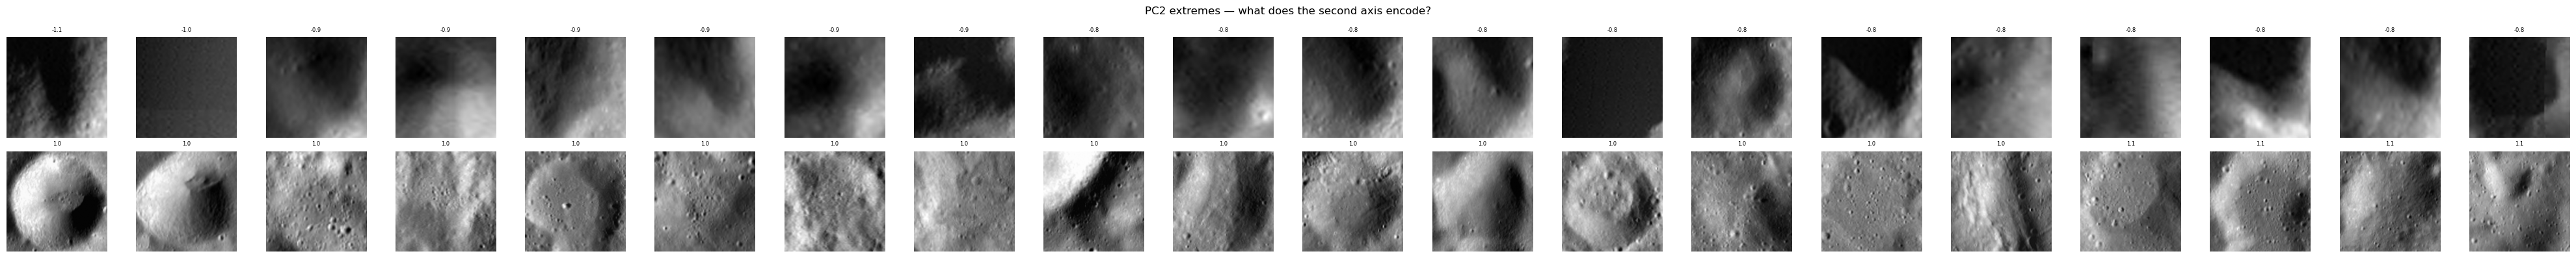

In [12]:
pc2_vals = coords_pca[:, 1]
low_idx  = np.argsort(pc2_vals)[:20]
high_idx = np.argsort(pc2_vals)[-20:]

fig, axes = plt.subplots(2, 20, figsize=(40, 4))
fig.suptitle("PC2 extremes — what does the second axis encode?")
for j, i in enumerate(low_idx):
    img = TF.center_crop(
        torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), 224
    ).squeeze().numpy()
    axes[0, j].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[0, j].set_title(f"{pc2_vals[i]:.1f}", fontsize=6)
    axes[0, j].axis('off')

for j, i in enumerate(high_idx):
    img = TF.center_crop(
        torch.from_numpy(np.array(craters[i, 0])).unsqueeze(0), 224
    ).squeeze().numpy()
    axes[1, j].imshow(img, cmap='gray', vmin=0, vmax=1)
    axes[1, j].set_title(f"{pc2_vals[i]:.1f}", fontsize=6)
    axes[1, j].axis('off')

axes[0, 0].set_ylabel("Low PC2", fontsize=10)
axes[1, 0].set_ylabel("High PC2", fontsize=10)
plt.tight_layout()
plt.savefig('pc2_extremes.png', dpi=200)

In [ ]:
from scipy import ndimage

batch_size = 2000
brightness = np.zeros(N)
sobel_vals = np.zeros(N)

for i in range(0, N, batch_size):
    if i % 20000 == 0: print(f"  {i}/{N}")
    batch = np.array(craters[i:i+batch_size, 0])
    # center crop
    batch_t = TF.center_crop(torch.from_numpy(batch).unsqueeze(1), INPUT_SIZE).squeeze(1).numpy()
    brightness[i:i+batch_size] = batch_t.mean(axis=(1,2))
    for j, img in enumerate(batch_t):
        sx = ndimage.sobel(img, axis=0)
        sy = ndimage.sobel(img, axis=1)
        sobel_vals[i+j] = np.sqrt(sx**2 + sy**2).mean()

# scatter PC1 vs brightness and sobel
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sub = np.random.default_rng(42).choice(N, size=10000, replace=False)

axes[0].scatter(coords_pca[sub, 1], brightness[sub], s=1, alpha=0.3)
axes[0].set_xlabel("PC2"); axes[0].set_ylabel("Brightness")
axes[0].set_title(f"PC2 vs Brightness  r={np.corrcoef(coords_pca[:,1], brightness)[1,0]:.3f}")

axes[1].scatter(coords_pca[sub, 1], sobel_vals[sub], s=1, alpha=0.3)
axes[1].set_xlabel("PC2"); axes[1].set_ylabel("Sobel (texture)")
axes[1].set_title(f"PC2 vs Sobel  r={np.corrcoef(coords_pca[:,1], sobel_vals)[1,0]:.3f}")

plt.tight_layout()
plt.savefig('pc2_vs_image_stats.png', dpi=200)

  0/152103
  20000/152103
  40000/152103
  60000/152103
  80000/152103
  100000/152103
  120000/152103


Processing 10000 craters...


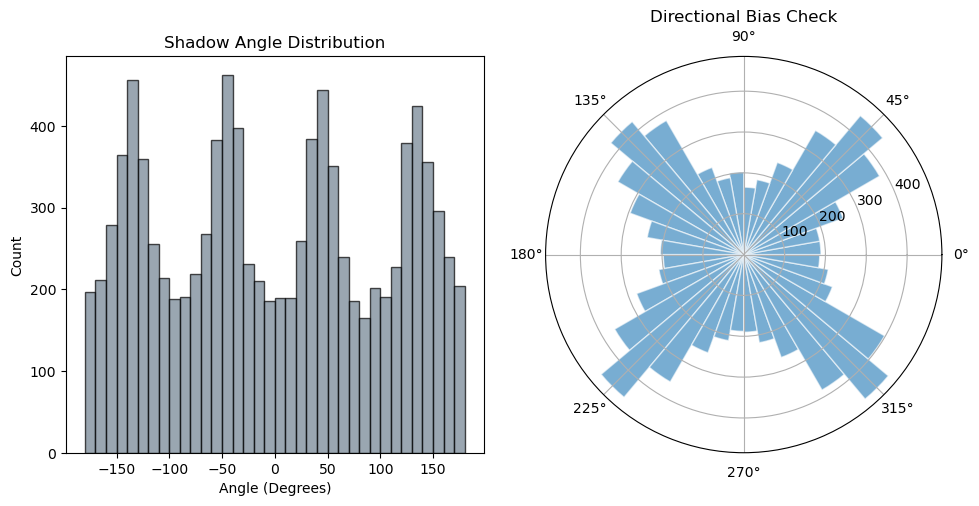

Mean Angle: -0.79°
Std Dev:    103.97°


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import os

# -- Config --
PATH = 'data/processed_wac_100m_new/sigma/100/craters_aug.dat'
IMG_SIZE = 128      # Based on your training script
CROP_SIZE = 48      # Focus on the inner crater to avoid background noise
NUM_SAMPLES = 10000 # Use a sample for speed

def get_shadow_angle_distribution(path):
    # 1. Load data
    N = os.path.getsize(path) // (1 * IMG_SIZE * IMG_SIZE * 4)
    data = np.memmap(path, dtype=np.float32, mode='r', shape=(N, 1, IMG_SIZE, IMG_SIZE))
    
    indices = np.random.choice(N, size=min(NUM_SAMPLES, N), replace=False)
    angles = []

    # Center coordinates for vector math
    cx, cy = CROP_SIZE // 2, CROP_SIZE // 2
    
    start = (IMG_SIZE - CROP_SIZE) // 2
    end = start + CROP_SIZE

    print(f"Processing {len(indices)} craters...")

    for i in indices:
        # 2. Center Crop
        img = data[i, 0, start:end, start:end]
        
        # 3. Identify "Dark Side" 
        # We take pixels below the 10th percentile as the "shadow"
        threshold = np.percentile(img, 10)
        shadow_mask = img <= threshold
        
        coords = np.argwhere(shadow_mask)
        
        if len(coords) > 0:
            # 4. Calculate Centroid of Shadow
            y_mean, x_mean = coords.mean(axis=0)
            
            # 5. Get Angle (atan2 returns radians, we convert to degrees)
            # Offset by center to get direction vector
            angle = np.degrees(np.arctan2(y_mean - cy, x_mean - cx))
            angles.append(angle)

    return np.array(angles)

# -- Run and Plot --
angles = get_shadow_angle_distribution(PATH)

plt.figure(figsize=(10, 5))

# Standard Histogram
plt.subplot(1, 2, 1)
plt.hist(angles, bins=36, color='slategray', edgecolor='black', alpha=0.7)
plt.title("Shadow Angle Distribution")
plt.xlabel("Angle (Degrees)")
plt.ylabel("Count")

# Polar Plot (more intuitive for directions)
plt.subplot(1, 2, 2, projection='polar')
rads = np.deg2rad(angles)
plt.hist(rads, bins=36, color='tab:blue', alpha=0.6, edgecolor='white')
plt.title("Directional Bias Check")

plt.tight_layout()
plt.show()

print(f"Mean Angle: {np.mean(angles):.2f}°")
print(f"Std Dev:    {np.std(angles):.2f}°")